/tmp/ipykernel_57116/1333649226.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('hsv', n**3)


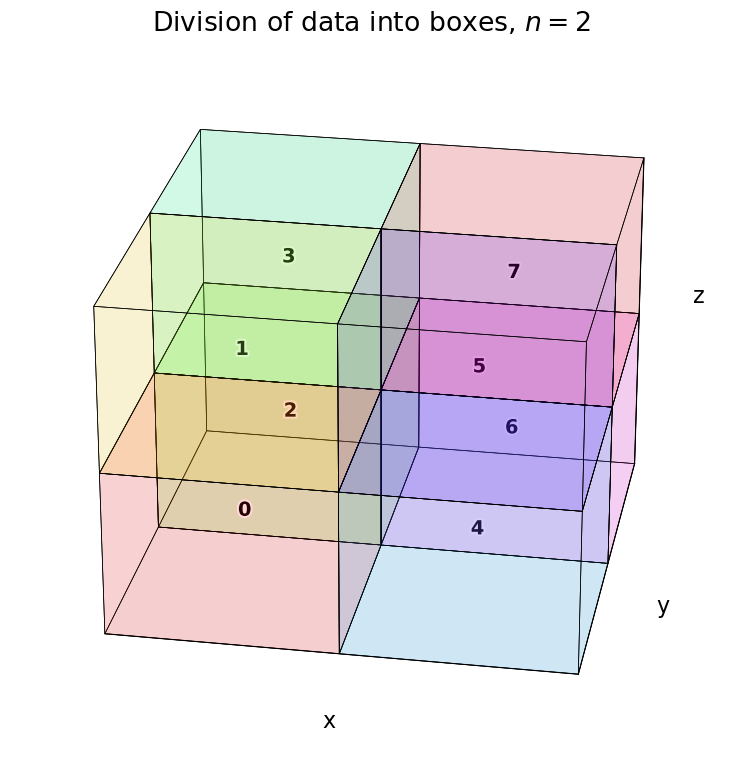

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
import matplotlib.cm as cm
import matplotlib.patheffects as path_effects
import matplotlib
font = {'size'   : 16}
matplotlib.rc('font', **font)

def create_boxes(n):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Create a colormap
    colors = cm.get_cmap('hsv', n**3)

    # Box dimensions
    dx = dy = dz = 1

    box_number = 0
    for i in range(n):  # x
        for j in range(n):  # y (along 0-2)
            for k in range(n):  # z (along 0-1)
                x = i
                y = j
                z = k

                # Define vertices of the box
                verts = [
                    [(x, y, z), (x+dx, y, z), (x+dx, y+dy, z), (x, y+dy, z)],  # bottom face
                    [(x, y, z+dz), (x+dx, y, z+dz), (x+dx, y+dy, z+dz), (x, y+dy, z+dz)],  # top face
                    [(x, y, z), (x, y+dy, z), (x, y+dy, z+dz), (x, y, z+dz)],  # left face
                    [(x+dx, y, z), (x+dx, y+dy, z), (x+dx, y+dy, z+dz), (x+dx, y, z+dz)],  # right face
                    [(x, y, z), (x+dx, y, z), (x+dx, y, z+dz), (x, y, z+dz)],  # front face
                    [(x, y+dy, z), (x+dx, y+dy, z), (x+dx, y+dy, z+dz), (x, y+dy, z+dz)]  # back face
                ]

                ax.add_collection3d(Poly3DCollection(verts,
                                                     facecolors=colors(box_number),
                                                     edgecolors='k', linewidths=0.5, alpha=0.08))

                # Place the number just above the center so it doesn't get hidden
                label = ax.text(x+0.5, y+0.5, z+0.5, f"{box_number}",
                                color='black', ha='center', va='center', fontsize=14, weight='bold')
                label.set_path_effects([
                    path_effects.Stroke(linewidth=3, foreground='white'),
                    path_effects.Normal()
                ])

                box_number += 1

    ax.set_xlim([0, n])
    ax.set_ylim([0, n])
    ax.set_zlim([0, n])
    ax.set_xlabel('x', labelpad=12) 
    ax.set_ylabel('y', labelpad=12) 
    ax.set_zlabel('z', labelpad=12) 
    ax.set_title(f"Division of data into boxes, $n=${n}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    # Adjust viewing angle to position y on left and z vertically
    ax.view_init(elev=25, azim=280)

    plt.tight_layout()
    plt.savefig("../thesis/images/boxes.pdf", bbox_inches='tight')
    plt.show()


# Set n (e.g. n=3 for demonstration; increase as needed, but larger n will slow down rendering)
create_boxes(n=2)